<a href="https://colab.research.google.com/github/Wilson1994/Analysis_Cafe_Sales/blob/main/EDA_cafe_sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Analysis Cafe Sales

Cafe Sales - Dirty Data for Cleaning Training


**Overview**

The Dirty Cafe Sales dataset contains 10,000 rows of synthetic data representing sales transactions in a cafe. This dataset is intentionally "dirty," with missing values, inconsistent data, and errors introduced to provide a realistic scenario for data cleaning and exploratory data analysis (EDA). It can be used to practice cleaning techniques, data wrangling, and feature engineering.

**File Information**

- File Name: dirty_cafe_sales.csv
- Number of Rows: 10,000
- Number of Columns: 8


- `Transaction ID`	A unique identifier for each transaction. Always present and unique.	TXN_1234567
- `Item`	The name of the item purchased. May contain missing or invalid values (e.g., "ERROR").	Coffee, Sandwich
- `Quantity`	The quantity of the item purchased. May contain missing or invalid values.	1, 3, UNKNOWN
- `Price Per Unit`	The price of a single unit of the item. May contain missing or invalid values.	2.00, 4.00
- `Total Spent`	The total amount spent on the transaction. Calculated as Quantity * Price Per Unit.	8.00, 12.00
- `Payment Method`	The method of payment used. May contain missing or invalid values (e.g., None, "UNKNOWN").	Cash, Credit Card
- `Location`	The location where the transaction occurred. May contain missing or invalid values.	In-store, Takeaway
- `Transaction Date`	The date of the transaction. May contain missing or incorrect values.	2023-01-01

`!pip instal numpy pandas metplotlib`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#Loading the dataset



In [2]:
url = 'https://raw.githubusercontent.com/Wilson1994/Analysis_Cafe_Sales/refs/heads/main/data/dirty_cafe_sales.csv'

df_origin = pd.read_csv(url)
df_origin.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [3]:
df = df_origin.copy()

#Primary diagnosis




In [4]:
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [6]:
print("Data types (raw):\n")
df.dtypes

Data types (raw):



,0
Transaction ID,object
Item,object
Quantity,object
Price Per Unit,object
Total Spent,object
Payment Method,object
Location,object
Transaction Date,object


Problem:
- Numeric columns (Quantity, Price Per Unit, Total Spent)
- Date columns (Transaction Date)

In [7]:
print("Missing values:\n")
missing = df.isnull().sum()

missing_pct = (missing / len(df) * 100).round(1)
missing_report = pd.DataFrame({
    'count': missing,
    '%': missing_pct
})
missing_report[missing_report['count'] > 0]

Missing values:



,count,%
Item,333,3.3
Quantity,138,1.4
Price Per Unit,179,1.8
Total Spent,173,1.7
Payment Method,2579,25.8
Location,3265,32.6
Transaction Date,159,1.6


In [8]:
print("Unique values:\n")

print("--- Item ---\n")
display(df['Item'].value_counts(dropna=False))

print("\n--- Payment Method ---\n")
display(df['Payment Method'].value_counts(dropna=False))

print("\n--- Location ---\n")
display(df['Location'].value_counts(dropna=False))


Unique values:

--- Item ---



,count
Item,
Juice,1171
Coffee,1165
Salad,1148
Cake,1139
Sandwich,1131
Smoothie,1096
Cookie,1092
Tea,1089
UNKNOWN,344



--- Payment Method ---



,count
Payment Method,
NaN,2579
Digital Wallet,2291
Credit Card,2273
Cash,2258
ERROR,306
UNKNOWN,293



--- Location ---



,count
Location,
NaN,3265
Takeaway,3022
In-store,3017
ERROR,358
UNKNOWN,338


In [9]:
print("Find line with 'ERROR' or 'UNKNOWN'\n")
#display(df.isin(['ERROR', 'UNKNOWN']).any())
display(df.isin(['ERROR', 'UNKNOWN']).sum())

mask_error = df.isin(['ERROR', 'UNKNOWN']).any(axis=1)
print(f"Find line with 'ERROR' or 'UNKNOWN': {mask_error.sum()}")

Find line with 'ERROR' or 'UNKNOWN'



,0
Transaction ID,0
Item,636
Quantity,341
Price Per Unit,354
Total Spent,329
Payment Method,599
Location,696
Transaction Date,301


Find line with 'ERROR' or 'UNKNOWN': 2845


## Data cleaning

- `df_origin` - origin dataset
- `df` - copy origin dataset

In [10]:
print("Rename columns:\n")

df.columns = df.columns.str.strip()
df = df.rename(columns= {
    'Transaction ID': 'transaction_id',
    'Item': 'item',
    'Quantity': 'quantity',
    'Price Per Unit': 'price_per_init',
    'Total Spent': 'total_spent',
    'Payment Method': 'payment_method',
    'Location': 'location',
    'Transaction Date': 'transaction_date'
})

print(list(df.columns))

Rename columns:

['transaction_id', 'item', 'quantity', 'price_per_init', 'total_spent', 'payment_method', 'location', 'transaction_date']


In [11]:
# 'ERROR' / 'UNKNOWN' - > NaN
df.replace(['ERROR', 'UNKNOWN', 'error', 'unknown', ''], np.nan, inplace=True)
df.head()

,transaction_id,item,quantity,price_per_init,total_spent,payment_method,location,transaction_date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,NaN,NaN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [12]:
# Converting numeric columns
for col in ['quantity', 'price_per_init', 'total_spent']:
  df[col] = pd.to_numeric(df[col], errors='coerce')

# Date conversion
df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')

In [13]:
#df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')
print('Converting columns:\n')

df.dtypes

Converting columns:



,0
transaction_id,object
item,object
quantity,float64
price_per_init,float64
total_spent,float64
payment_method,object
location,object
transaction_date,datetime64[ns]


In [14]:
# Extracring time signatures
df['year'] = df['transaction_date'].dt.year.astype('Int64')
df['month'] = df['transaction_date'].dt.month.astype('Int64')
df['month_name'] = df['transaction_date'].dt.strftime('%m')

df['weekday'] = df['transaction_date'].dt.day_name()
df['week'] = df['transaction_date'].dt.isocalendar().week.astype('Int64')

df[['transaction_date','year', 'month', 'month_name', 'weekday', 'week']].head()

,transaction_date,year,month,month_name,weekday,week
0,2023-09-08,2023,9,09,Friday,36
1,2023-05-16,2023,5,05,Tuesday,20
2,2023-07-19,2023,7,07,Wednesday,29
3,2023-04-27,2023,4,04,Thursday,17
4,2023-06-11,2023,6,06,Sunday,23


In [15]:
# Restoring total_spent (quantity * price)

mask_recoverable = (
    df['total_spent'].isna() &
    df['quantity'].notna() &
    df['price_per_init'].notna()
)

df.loc[mask_recoverable, 'total_spent'] = (
    df.loc[mask_recoverable, 'quantity'] *
    df.loc[mask_recoverable, 'price_per_init']
)

print(f"Restoring total_spent: {mask_recoverable.sum()} string (quantity * price) ")


Restoring total_spent: 462 string (quantity * price) 


In [16]:
# dict of median price

price_map = (
    df.dropna(subset=['item', 'price_per_init'])
    .groupby('item')['price_per_init']
    .median()
    .to_dict()
)

mask_price = df['price_per_init'].isna() & df['item'].notna()

df.loc[mask_price, 'price_per_init'] = df.loc[mask_price, 'item'].map(price_map)

df[58:59]

#mask_price.sum()

#df.loc[mask_price, 'item'].map(price_map)

print(f"Restoring price_per_init: {mask_price.sum()} string (mediana per item) ")


Restoring price_per_init: 479 string (mediana per item) 


In [17]:
type(df[mask_price])  # DataFrame
type(df[mask_price]['item'])  # Series
type(df[mask_price][['item', 'price_per_init']])  # DataFrame

type(df.loc[mask_price, 'item'])  # Series
type(df.loc[mask_price, ['item', 'price_per_init']])  # DataFrame


pandas.core.frame.DataFrame

In [18]:
# Restoring total_spent (quantity * price)

mask_recoverable2 = (
    df['total_spent'].isna() &
    df['quantity'].notna() &
    df['price_per_init'].notna()
)

df.loc[mask_recoverable2, 'total_spent'] = (
    df.loc[mask_recoverable2, 'quantity'] *
    df.loc[mask_recoverable2, 'price_per_init']
)

print(f"Restoring total_spent: {mask_recoverable2.sum()} string (quantity * price) ")


Restoring total_spent: 17 string (quantity * price) 


In [19]:
# fillna item -> mode
mode_item = df['item'].mode()[0]
#df['item'].fillna(mode_item, inplace=True)
df.fillna({'item': mode_item}, inplace=True)

In [20]:
df.fillna(
    {
        'payment_method': 'Unknown',
        'location': 'Unknown'
    },
    inplace=True
)

In [21]:
# Delate transaction_date where NaT or NaN
before = len(df)

df.dropna(subset=['transaction_date', 'quantity'], inplace=True)

after = len(df)

print(f"Delated {before - after} rows")

Delated 914 rows


In [22]:
df.columns

Index(['transaction_id', 'item', 'quantity', 'price_per_init', 'total_spent',
       'payment_method', 'location', 'transaction_date', 'year', 'month',
       'month_name', 'weekday', 'week'],
      dtype='object')

In [23]:
df[['item', 'quantity', 'price_per_init', 'total_spent',
       'payment_method', 'location', 'transaction_date', 'year', 'month',
       'month_name', 'weekday', 'week']].duplicated().sum()

np.int64(192)

In [24]:
# Delete duplicates
df.duplicated().sum() #0
df.drop_duplicates(inplace=True)

In [25]:
(df.quantity <= 0).sum()  # 0
(df.price_per_init <= 0).sum()  # 0
(df.total_spent <= 0).sum()  # 0

np.int64(0)

In [26]:
(df['quantity'].isna() & df['price_per_init'].isna()).sum()

np.int64(0)

In [27]:
df.info()
#df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
Index: 9086 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    9086 non-null   object        
 1   item              9086 non-null   object        
 2   quantity          9086 non-null   float64       
 3   price_per_init    9038 non-null   float64       
 4   total_spent       9083 non-null   float64       
 5   payment_method    9086 non-null   object        
 6   location          9086 non-null   object        
 7   transaction_date  9086 non-null   datetime64[ns]
 8   year              9086 non-null   Int64         
 9   month             9086 non-null   Int64         
 10  month_name        9086 non-null   object        
 11  weekday           9086 non-null   object        
 12  week              9086 non-null   Int64         
dtypes: Int64(3), datetime64[ns](1), float64(3), object(6)
memory usage: 1020.4+ KB


In [28]:
#Restoring price_per_unit (total_spent / quantity)

mask_recoverable3 = (
    df['price_per_init'].isna() &
    df['total_spent'].notna() &
    df['quantity'].notna()
)
df.loc[mask_recoverable3, 'price_per_init'] = df.loc[mask_recoverable3, 'total_spent'] / df.loc[mask_recoverable3, 'quantity']
# mask_recoverable.sum()
print(f"Restoring price_per_init: {mask_recoverable3.sum()} (total_spent / quantity)")

Restoring price_per_init: 45 (total_spent / quantity)


In [33]:
# Drop NaN

df.dropna(subset=['total_spent'], inplace=True)

print(f"Delete rows with NaN (df['total_spent'].isna() & dsd['price_per_init'].isna())")

Delete rows with NaN (df['total_spent'].isna() & dsd['price_per_init'].isna())


In [34]:
df.isna().sum().sum()

np.int64(0)

In [43]:
# Check quantity * price_per_init = total_spent

mask_total_spent = (df.quantity * df.price_per_init != df.total_spent)
print(f"Uncorect rows total_spent: {mask_total_spent.sum()}")

Uncorect rows total_spent: 0


In [39]:
# Rext field are standartized (Titel case)

for col in ['item', 'payment_method', 'location']:
  df[col] = df[col].str.strip().str.title()

print("Text fields are standartized (Titel Case)")

Text fields are standartized (Titel Case)


## Cleaning result

In [50]:
# df_origin = name_your_Dataframe
# df = name_your_Dataframe


print("Cleaning results:\n")

print(f"Rows before: {len(df_origin)}")
print(f"Rows after: {len(df)}")
print(f"Loss: {len(df_origin) - len(df)} ({(len(df_origin) - len(df)) / len(df_origin) * 100:.1f}%)")

print("\nResidual gaps")
remaining = df.isna().sum()
print(remaining[remaining > 0] if remaining.any() else "No gaps")

print("\nData types after cleanup:")
display(df.dtypes)

print("\nStatistics")
print(df[['quantity', 'price_per_init', 'total_spent']].describe().round(2))
#print(f"{}")

Cleaning results:

Rows before: 10000
Rows after: 9083
Loss: 917 (9.2%)

Residual gaps
No gaps

Data types after cleanup:


,0
transaction_id,object
item,object
quantity,float64
price_per_init,float64
total_spent,float64
payment_method,object
location,object
transaction_date,datetime64[ns]
year,Int64
month,Int64



Statistics
       quantity  price_per_init  total_spent
count   9083.00         9083.00      9083.00
mean       3.03            2.95         8.93
std        1.42            1.28         6.00
min        1.00            1.00         1.00
25%        2.00            2.00         4.00
50%        3.00            3.00         8.00
75%        4.00            4.00        12.00
max        5.00            5.00        25.00


## Feature Engineering

In [55]:
# Season
season_map = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
}
df['season'] = df['month'].map(season_map)

#df[['month', 'season']].head()

In [60]:
# Is weekend
df['is_weekend'] = df['weekday'].isin(['Saturday', 'Sunday'])

In [67]:
# Check amount category
df['spend_tier'] = pd.cut(
    df['total_spent'],
    bins=[0, 5, 10, 20, 1000],
    labels=['Low', 'Medium', 'Hight', 'Premium']
)

In [69]:
print("New attributes: season, is_weekend', spend_tier")

New attributes: season, is_weekend', spend_tier


In [68]:
df.head()

,transaction_id,item,quantity,price_per_init,total_spent,payment_method,location,transaction_date,year,month,month_name,weekday,week,season,is_weekend,spend_tier
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,2023,9,09,Friday,36,Autumn,False,Low
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-Store,2023-05-16,2023,5,05,Tuesday,20,Spring,False,Hight
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-Store,2023-07-19,2023,7,07,Wednesday,29,Summer,False,Low
3,TXN_7034554,Salad,2.0,5.0,10.0,Unknown,Unknown,2023-04-27,2023,4,04,Thursday,17,Spring,False,Medium
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-Store,2023-06-11,2023,6,06,Sunday,23,Summer,True,Low


## Fast EDA (verificatoin graphs)

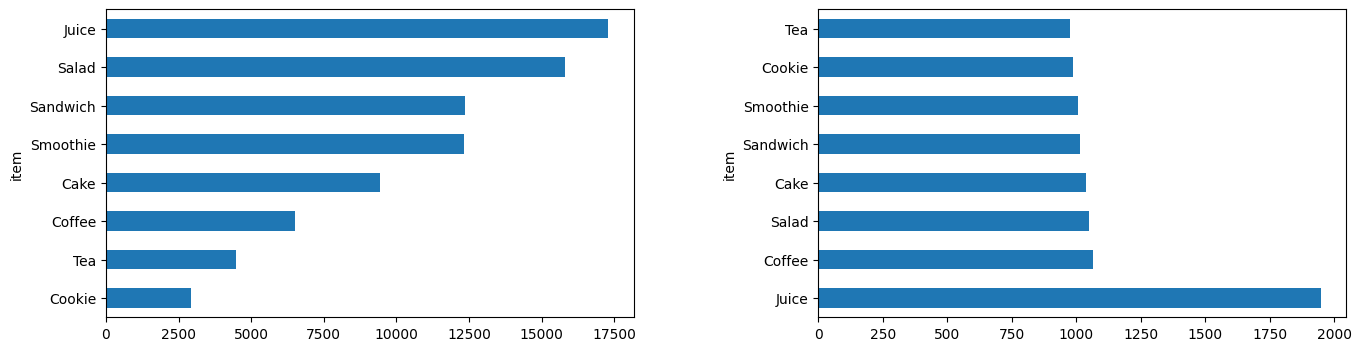

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
fig.suptitle("")
plt.subplots_adjust(hspace=0.45, wspace=0.35)

# total_spent per item
ax = axes[0]
df.groupby('item')['total_spent'].sum().sort_values().plot(kind='barh', ax=ax)

# count per item
ax = axes[1]
df['item'].value_counts().plot(kind='barh', ax=ax)

plt.show()

<Axes: ylabel='item'>

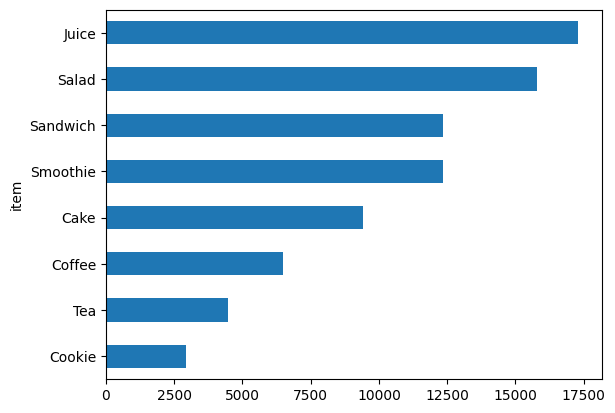

In [71]:
df.groupby('item')['total_spent'].sum().sort_values().plot.barh()